# 01 - Dataset Inspection

**FlexScaleSR: satellite multispectral super-resolution**

## 1. Project introduction

We are given pairs of satellite images of the same patch of ground:

| | role | source | resolution |
|---|---|---|---|
| **LR** | **low-resolution INPUT** | Sentinel-2 | about 10 m per pixel |
| **HR** | **high-resolution GROUND TRUTH** | a sharper sensor | about 1.5 m per pixel |

The task is to learn the mapping

```
LR image  ->  super-resolution model  ->  HR image
```

**HR is not a segmentation mask.** It contains continuous reflectance values, one
per band, exactly like the LR image. This is an image-to-image regression
problem, so the metrics are PSNR / SSIM / MAE / RMSE / SAM / ERGAS, and never
IoU or Dice.

This notebook checks what is *actually* in the files. Every claim below is
measured, not assumed.

In [1]:
import sys, os

# Make `import src...` work no matter where the notebook is launched from.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
PROJECT_ROOT = os.getcwd()
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
import cv2

from src.data import (list_pairs, read_tif, load_pair, reorder_lr_bands,
                      inspect_split, check_dataset, geo_info,
                      LR_TO_CANONICAL, CANONICAL_BAND_NAMES)
from src.train_utils import load_config
from src.visualize import to_rgb, to_nir, show_pair

pd.set_option("display.width", 140)
print("project root:", PROJECT_ROOT)

project root: E:\Hackathon


## 2. Dataset paths

In [2]:
cfg = load_config("configs/baseline.yaml")
ROOT = "."                      # we already chdir'd to the project root
HR_SCALE = cfg["data"]["hr_scale"]

for split in ["train", "val", "test"]:
    for sub in ["LR", "HR"]:
        print(os.path.join(ROOT, split, sub), "->", os.path.isdir(os.path.join(ROOT, split, sub)))
print()
print("HR scale from config:", HR_SCALE)

.\train\LR -> True
.\train\HR -> True
.\val\LR -> True
.\val\HR -> True
.\test\LR -> True
.\test\HR -> True

HR scale from config: 10000.0


## 3. Count LR / HR files
## 4. Match LR and HR filenames

`check_dataset()` reads every file and reports problems. It looks for missing
partners, duplicate names, wrong dtypes, wrong band counts, unreadable files,
and geographic overlap between splits.

In [3]:
report = check_dataset(ROOT)

rows = []
for split, s in report["splits"].items():
    rows.append({"split": split, "LR files": s["n_lr"], "HR files": s["n_hr"],
                 "matched pairs": s["n_paired"],
                 "LR shape": s["lr_shapes"][0], "LR dtype": s["lr_dtypes"][0],
                 "HR dtype": s["hr_dtypes"][0],
                 "distinct HR shapes": s["n_distinct_hr_shapes"],
                 "HR height range": s["hr_height_range"],
                 "HR width range": s["hr_width_range"]})
display(pd.DataFrame(rows))

print("problems found:", report["problems"] if report["problems"] else "NONE")

,split,LR files,HR files,matched pairs,LR shape,LR dtype,HR dtype,distinct HR shapes,HR height range,HR width range
0,train,100,100,100,"(48, 48, 4)",float32,uint16,22,"(307, 336)","(307, 336)"
1,val,20,20,20,"(48, 48, 4)",float32,uint16,11,"(313, 330)","(310, 329)"
2,test,20,20,20,"(48, 48, 4)",float32,uint16,12,"(310, 333)","(309, 330)"


problems found: NONE


### Data leakage check

Training must never see validation or test ground. We compare the geographic
footprint of every HR tile across splits and count overlaps. **Zero overlaps
means the splits are geographically disjoint.**

In [4]:
for pair, n in report["leakage"].items():
    print("{:20s} overlapping footprints: {}".format(pair, n))
print()
print("splits are geographically disjoint:", all(v == 0 for v in report["leakage"].values()))

train vs val         overlapping footprints: 0
train vs test        overlapping footprints: 0
val vs test          overlapping footprints: 0

splits are geographically disjoint: True


## 5. Inspect TIFF metadata
## 6. Inspect shapes
## 7. Inspect channels
## 8. Inspect dtype
## 9. Inspect value ranges

One row per file: shape, dtype, statistics, CRS, pixel size, compression, nodata.

In [5]:
lr_info = pd.DataFrame(inspect_split(ROOT, "train", "LR"))
hr_info = pd.DataFrame(inspect_split(ROOT, "train", "HR"))

print("=== train/LR (first 5 rows) ===")
display(lr_info.head())
print("=== train/HR (first 5 rows) ===")
display(hr_info.head())

=== train/LR (first 5 rows) ===


,file,height,width,channels,dtype,min,max,mean,std,n_unique,zero_fraction,finite,pixel_size_x,pixel_size_y,origin_x,origin_y,epsg,compression,nodata
0,1.tif,48,48,4,float32,0.0101,0.3694,0.091009,0.104679,1267,0.0,True,0.000093,0.000090,-70.037884,-12.955089,4326,COMPRESSION.ADOBE_DEFLATE,None
1,10.tif,48,48,4,float32,0.0622,0.6256,0.287139,0.119600,1948,0.0,True,0.000098,0.000092,49.357544,24.811754,4326,COMPRESSION.ADOBE_DEFLATE,None
2,100.tif,48,48,4,float32,0.0148,0.6076,0.169549,0.067354,1615,0.0,True,0.000111,0.000089,118.748221,34.136838,4326,COMPRESSION.ADOBE_DEFLATE,None
3,11.tif,48,48,4,float32,0.0486,0.4008,0.172937,0.071886,1572,0.0,True,0.000091,0.000090,10.021186,10.465713,4326,COMPRESSION.ADOBE_DEFLATE,None
4,12.tif,48,48,4,float32,0.0298,0.3946,0.170266,0.069801,1834,0.0,True,0.000091,0.000091,-4.740090,11.831930,4326,COMPRESSION.ADOBE_DEFLATE,None


=== train/HR (first 5 rows) ===


,file,height,width,channels,dtype,min,max,mean,std,n_unique,zero_fraction,finite,pixel_size_x,pixel_size_y,origin_x,origin_y,epsg,compression,nodata
0,1.tif,318,322,4,uint16,7.0,4701.0,585.083851,602.357786,3121,0.0,True,0.000014,0.000014,-70.037891,-12.955081,4326,COMPRESSION.ADOBE_DEFLATE,None
1,10.tif,325,317,4,uint16,647.0,4634.0,1395.438546,617.803623,3784,0.0,True,0.000015,0.000014,49.357531,24.811765,4326,COMPRESSION.ADOBE_DEFLATE,None
2,100.tif,314,326,4,uint16,171.0,5181.0,1177.923303,560.405213,3649,0.0,True,0.000016,0.000014,118.748214,34.136846,4326,COMPRESSION.ADOBE_DEFLATE,None
3,11.tif,318,321,4,uint16,177.0,8369.0,1220.829958,617.588543,3426,0.0,True,0.000014,0.000014,10.021174,10.465721,4326,COMPRESSION.ADOBE_DEFLATE,None
4,12.tif,322,318,4,uint16,337.0,14209.0,1481.278729,624.950157,3596,0.0,True,0.000014,0.000014,-4.740098,11.831938,4326,COMPRESSION.ADOBE_DEFLATE,None


In [6]:
cols = ["height", "width", "channels", "min", "max", "mean", "std",
        "pixel_size_x", "pixel_size_y"]
print("=== train/LR summary ===")
display(lr_info[cols].describe().T[["min", "max", "mean"]].round(6))
print("=== train/HR summary ===")
display(hr_info[cols].describe().T[["min", "max", "mean"]].round(6))

print("LR dtypes :", lr_info["dtype"].unique(), " | channels:", lr_info["channels"].unique())
print("HR dtypes :", hr_info["dtype"].unique(), " | channels:", hr_info["channels"].unique())
print("CRS (EPSG):", set(lr_info["epsg"]) | set(hr_info["epsg"]), " (4326 = WGS84 lat/lon)")
print("compression:", set(hr_info["compression"]))
print("nodata values:", set(hr_info["nodata"].astype(str)))
print("all pixels finite:", bool(lr_info["finite"].all() and hr_info["finite"].all()))

=== train/LR summary ===


,min,max,mean
height,48.000000,48.000000,48.000000
width,48.000000,48.000000,48.000000
channels,4.000000,4.000000,4.000000
min,0.000100,0.876800,0.044795
max,0.204200,1.899200,0.494975
mean,0.041806,0.970448,0.161628
std,0.036718,0.137478,0.083504
pixel_size_x,0.000089,0.000331,0.000119
pixel_size_y,0.000086,0.000094,0.000090


=== train/HR summary ===


,min,max,mean
height,307.000000,336.000000,320.800000
width,307.000000,336.000000,320.030000
channels,4.000000,4.000000,4.000000
min,0.000000,7794.000000,268.740000
max,2083.000000,38301.000000,8525.770000
mean,278.997086,9454.705548,1234.900522
std,272.906357,1665.663215,691.388793
pixel_size_x,0.000013,0.000051,0.000018
pixel_size_y,0.000013,0.000014,0.000014


LR dtypes : ['float32']  | channels: [4]
HR dtypes : ['uint16']  | channels: [4]
CRS (EPSG): {4326}  (4326 = WGS84 lat/lon)
compression: {'COMPRESSION.ADOBE_DEFLATE'}
nodata values: {'None'}
all pixels finite: True


### Ground sample distance (GSD)

Pixel size is stored in **degrees**, not metres, because the CRS is EPSG:4326.
Converting needs care: one degree of latitude is about 110540 m everywhere, but
one degree of **longitude** shrinks towards the poles by a factor of
`cos(latitude)`. These tiles span latitudes from about -75 to +72, so ignoring
that factor would overstate the pixel size by 30 percent.

In [7]:
M_PER_DEG_LON = 111320.0
M_PER_DEG_LAT = 110540.0

def gsd_metres(info):
    """Mean pixel size in metres, correcting longitude for latitude."""
    cos_lat = np.cos(np.radians(info["origin_y"].values))
    x_m = (info["pixel_size_x"].values * M_PER_DEG_LON * cos_lat).mean()
    y_m = (info["pixel_size_y"].values * M_PER_DEG_LAT).mean()
    return x_m, y_m

lr_x, lr_y = gsd_metres(lr_info)
hr_x, hr_y = gsd_metres(hr_info)
lr_gsd, hr_gsd = (lr_x + lr_y) / 2, (hr_x + hr_y) / 2

print("tile latitudes range from {:.1f} to {:.1f} degrees".format(
    hr_info["origin_y"].min(), hr_info["origin_y"].max()))
print()
print("LR pixel size: {:.2f} m across, {:.2f} m down".format(lr_x, lr_y))
print("HR pixel size: {:.2f} m across, {:.2f} m down".format(hr_x, hr_y))
print("resolution ratio LR/HR: {:.2f}x".format(lr_gsd / hr_gsd))
print()
print("This confirms the expected 10 m Sentinel-2 input and 1.5 m target.")

tile latitudes range from -74.7 to 71.9 degrees

LR pixel size: 9.98 m across, 9.98 m down
HR pixel size: 1.50 m across, 1.49 m down
resolution ratio LR/HR: 6.67x

This confirms the expected 10 m Sentinel-2 input and 1.5 m target.


## 10. Verify the HR scale factor

The claim is: **HR uint16 = reflectance x 10000**.

Two pieces of evidence:

1. Dividing HR by 10000 must land in the reflectance range that LR already occupies.
2. HR and LR cover the same ground, so their band means should be comparable.

In [8]:
names = [n for n, _, _ in list_pairs(ROOT, "train")]
lr_means, hr_means = [], []
for n in names:
    lr_raw = read_tif(os.path.join(ROOT, "train", "LR", n)).astype(np.float64)
    hr_raw = read_tif(os.path.join(ROOT, "train", "HR", n)).astype(np.float64)
    lr_means.append(lr_raw.reshape(-1, 4).mean(0))
    hr_means.append(hr_raw.reshape(-1, 4).mean(0))
lr_means = np.array(lr_means); hr_means = np.array(hr_means)

print("LR mean reflectance per band      :", np.round(lr_means.mean(0), 4))
print("HR raw uint16 mean per band       :", np.round(hr_means.mean(0), 1))
print("HR / 10000                        :", np.round(hr_means.mean(0) / 1e4, 4))
print()
print("overall LR mean {:.4f}  vs  overall HR/10000 mean {:.4f}".format(
    lr_means.mean(), (hr_means / 1e4).mean()))
print("ratio HR/LR: {:.3f}".format((hr_means / 1e4).mean() / lr_means.mean()))

LR mean reflectance per band      : [0.101  0.1303 0.1483 0.2669]
HR raw uint16 mean per band       : [1143.2 1028.8  868.8 1898.7]
HR / 10000                        : [0.1143 0.1029 0.0869 0.1899]

overall LR mean 0.1616  vs  overall HR/10000 mean 0.1235
ratio HR/LR: 0.764


**Reading of the result.** After dividing by 10000 the HR values sit in the
same reflectance range as LR, so 10000 is the right encoding scale.

There is still a systematic brightness difference of roughly 0.76x between the
two. That is **not** a scaling mistake: LR and HR come from different sensors,
acquired on different dates, so their absolute calibration differs. We keep
10000 because it is the physically meaningful reflectance convention, and the
network learns the remaining offset. It is set in `configs/baseline.yaml` as
`data.hr_scale` so it can be changed in one place.

## 11. Verify the band order

The metadata inside the HR files labels the bands "Blue, Green, Red, NIR".
**We do not trust that label** - we test it against the pixels.

Naive correlation does not work, because all visible bands are bright in bright
scenes and dark in dark scenes, so everything correlates with everything. The
fix is to remove overall brightness first: divide each image's band means by
that image's own average. What is left is the *colour* of the scene, and colour
is what identifies a band.

In [9]:
lr_chroma = lr_means / lr_means.mean(axis=1, keepdims=True)
hr_chroma = hr_means / hr_means.mean(axis=1, keepdims=True)

def corr(a, b):
    a = a - a.mean(); b = b - b.mean()
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

lr_labels = ["LR0 B02/Blue", "LR1 B03/Green", "LR2 B04/Red", "LR3 B08/NIR"]
M = pd.DataFrame(
    [[corr(hr_chroma[:, i], lr_chroma[:, j]) for j in range(4)] for i in range(4)],
    index=["HR0", "HR1", "HR2", "HR3"], columns=lr_labels)
display(M.round(3))

best = M.values.argmax(axis=1)
print("each HR band matches:", [lr_labels[b] for b in best])

,LR0 B02/Blue,LR1 B03/Green,LR2 B04/Red,LR3 B08/NIR
HR0,0.601,0.777,0.921,-0.855
HR1,0.775,0.837,0.666,-0.800
HR2,0.697,0.630,0.375,-0.576
HR3,-0.768,-0.844,-0.767,0.850


each HR band matches: ['LR2 B04/Red', 'LR1 B03/Green', 'LR0 B02/Blue', 'LR3 B08/NIR']


In [10]:
print("mean colour signature (band mean / image mean):")
print("  LR  [B,  G,  R,  NIR] :", np.round(lr_chroma.mean(0), 4))
print("  HR  [?,  ?,  ?,  ?  ] :", np.round(hr_chroma.mean(0), 4))
print()
print("HR0 signature %.4f matches LR Red   %.4f" % (hr_chroma.mean(0)[0], lr_chroma.mean(0)[2]))
print("HR1 signature %.4f matches LR Green %.4f" % (hr_chroma.mean(0)[1], lr_chroma.mean(0)[1]))
print("HR2 signature %.4f matches LR Blue  %.4f" % (hr_chroma.mean(0)[2], lr_chroma.mean(0)[0]))
print("HR3 signature %.4f matches LR NIR   %.4f" % (hr_chroma.mean(0)[3], lr_chroma.mean(0)[3]))

mean colour signature (band mean / image mean):
  LR  [B,  G,  R,  NIR] : [0.5498 0.7538 0.8541 1.8423]
  HR  [?,  ?,  ?,  ?  ] : [0.8541 0.777  0.6176 1.7513]

HR0 signature 0.8541 matches LR Red   0.8541
HR1 signature 0.7770 matches LR Green 0.7538
HR2 signature 0.6176 matches LR Blue  0.5498
HR3 signature 1.7513 matches LR NIR   1.8423


### Conclusion on band order

| | stored order | |
|---|---|---|
| LR | `[B, G, R, NIR]` | matches its own metadata (B02, B03, B04, B08) |
| HR | `[R, G, B, NIR]` | **contradicts** its metadata label, which says "Blue, Green, Red, NIR" |

So the HR files are mislabelled, and we must trust the pixels rather than the tag.

We pick `[R, G, B, NIR]` as the **canonical** order and permute LR into it:

```python
def reorder_lr_bands(x):
    return x[..., [2, 1, 0, 3]]
```

Channel 3 (NIR) maps to channel 3. **NIR never moves.**

In [11]:
raw = read_tif(os.path.join(ROOT, "train", "LR", names[0]))
fixed = reorder_lr_bands(raw)
print("permutation used:", LR_TO_CANONICAL, "-> canonical", CANONICAL_BAND_NAMES)
for c, name in enumerate(CANONICAL_BAND_NAMES):
    src = LR_TO_CANONICAL[c]
    print("  canonical ch{} {:6s} <- LR ch{}   identical: {}".format(
        c, name, src, np.array_equal(fixed[..., c], raw[..., src])))
print("NIR stayed in place:", np.array_equal(fixed[..., 3], raw[..., 3]))

permutation used: [2, 1, 0, 3] -> canonical ['Red', 'Green', 'Blue', 'NIR']
  canonical ch0 Red    <- LR ch2   identical: True
  canonical ch1 Green  <- LR ch1   identical: True
  canonical ch2 Blue   <- LR ch0   identical: True
  canonical ch3 NIR    <- LR ch3   identical: True
NIR stayed in place: True


## 12. Verify the spatial relationship

Do the LR and HR tiles actually cover the same ground? We compare their
georeferenced corners. If they line up, resizing LR to the HR size is the
correct operation and no cropping or shifting is needed.

In [12]:
rows = []
for n in names[:10]:
    g_lr = geo_info(os.path.join(ROOT, "train", "LR", n))
    g_hr = geo_info(os.path.join(ROOT, "train", "HR", n))
    lr_a = read_tif(os.path.join(ROOT, "train", "LR", n)).shape
    hr_a = read_tif(os.path.join(ROOT, "train", "HR", n)).shape
    rows.append({
        "file": n,
        "LR size": (lr_a[0], lr_a[1]), "HR size": (hr_a[0], hr_a[1]),
        "scale h": round(hr_a[0] / lr_a[0], 3), "scale w": round(hr_a[1] / lr_a[1], 3),
        "origin offset (HR px)": round(abs(g_lr["origin_x"] - g_hr["origin_x"])
                                       / g_hr["pixel_size_x"], 2),
        "LR extent deg": round(lr_a[1] * g_lr["pixel_size_x"], 6),
        "HR extent deg": round(hr_a[1] * g_hr["pixel_size_x"], 6),
    })
display(pd.DataFrame(rows))

,file,LR size,HR size,scale h,scale w,origin offset (HR px),LR extent deg,HR extent deg
0,1.tif,"(48, 48)","(318, 322)",6.625,6.708,0.52,0.004455,0.004452
1,2.tif,"(48, 48)","(322, 318)",6.708,6.625,0.59,0.007013,0.007009
2,3.tif,"(48, 48)","(322, 318)",6.708,6.625,0.59,0.005602,0.005599
3,4.tif,"(48, 48)","(336, 307)",7.000,6.396,0.50,0.007792,0.007802
4,5.tif,"(48, 48)","(322, 318)",6.708,6.625,0.59,0.004452,0.004449
5,6.tif,"(48, 48)","(309, 333)",6.438,6.938,0.58,0.006362,0.006365
6,7.tif,"(48, 48)","(322, 318)",6.708,6.625,0.59,0.004322,0.004320
7,8.tif,"(48, 48)","(317, 325)",6.604,6.771,0.85,0.006966,0.006981
8,9.tif,"(48, 48)","(321, 321)",6.688,6.688,0.90,0.004648,0.004660
9,10.tif,"(48, 48)","(325, 317)",6.771,6.604,0.90,0.004692,0.004703


The origin offset is well under one HR pixel and the ground extents match to
six decimal places. **LR and HR are co-registered and cover the same footprint.**

## 13. Visualize sample LR images
## 14. Visualize HR images
## 15. Visualize RGB
## 16. Visualize NIR

All images are shown in canonical `[R, G, B, NIR]` order, in reflectance, with a
2-98 percentile stretch. **NIR is drawn as its own grayscale panel**, never mixed
into the RGB picture - putting NIR in a colour channel makes a pretty image that
means nothing.

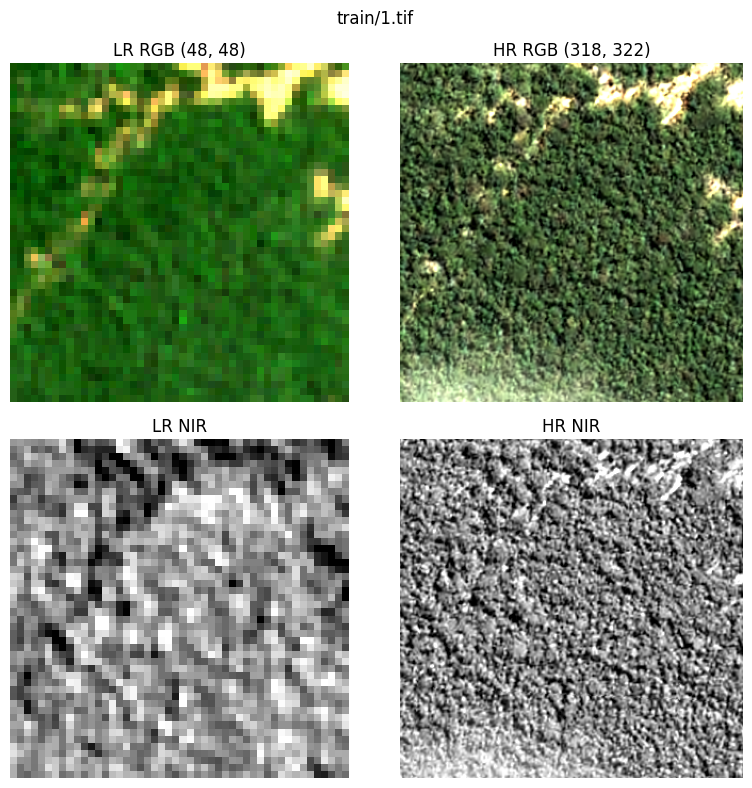

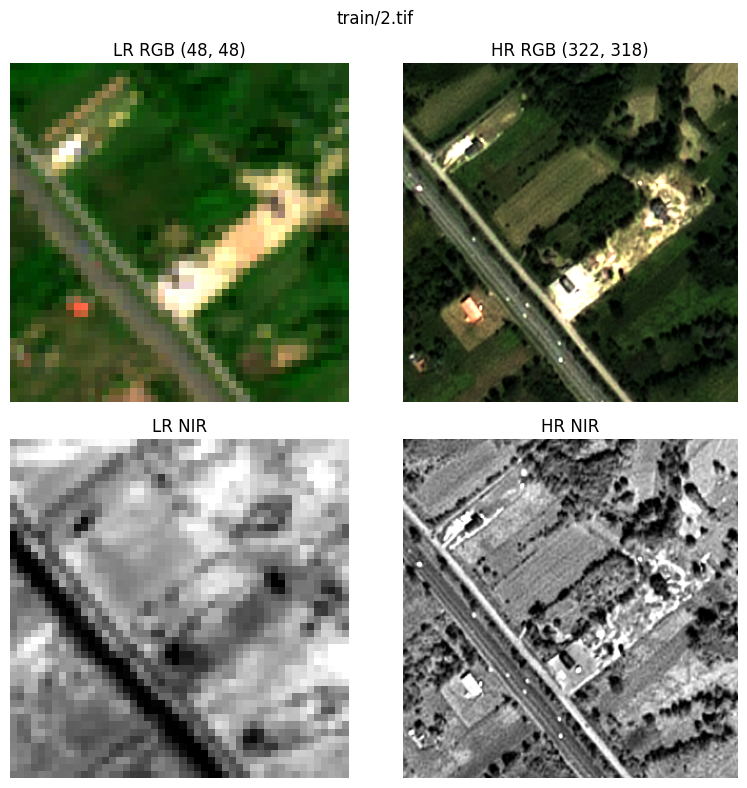

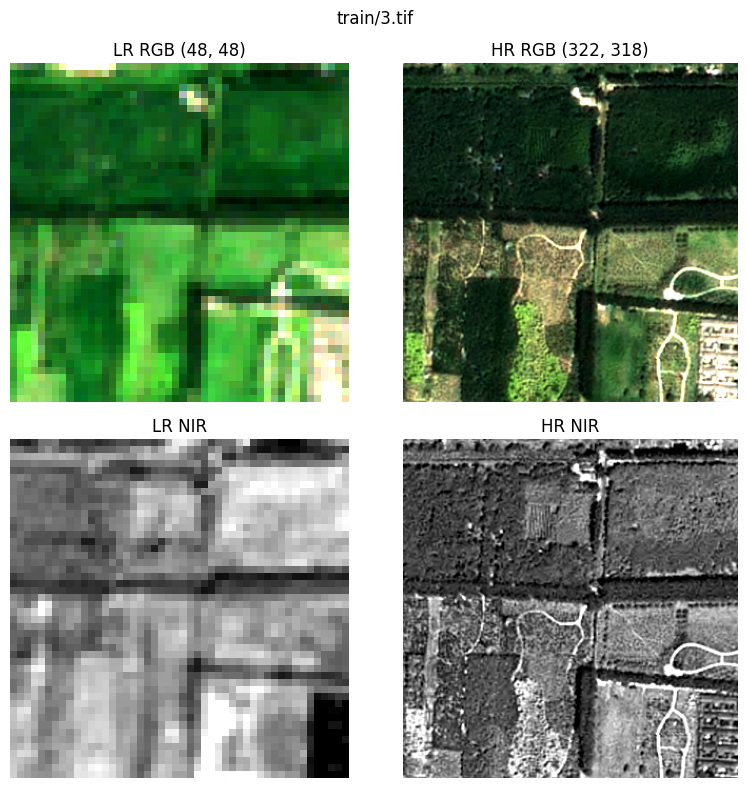

In [13]:
for n in names[:3]:
    lr, hr = load_pair(os.path.join(ROOT, "train", "LR", n),
                       os.path.join(ROOT, "train", "HR", n), HR_SCALE)
    show_pair(lr, hr, name="train/" + n)
    plt.show()

### Same scene, all four bands side by side

Vegetation is dark in Red and bright in NIR. Seeing that pattern is a good sanity
check that the bands really are what we think they are.

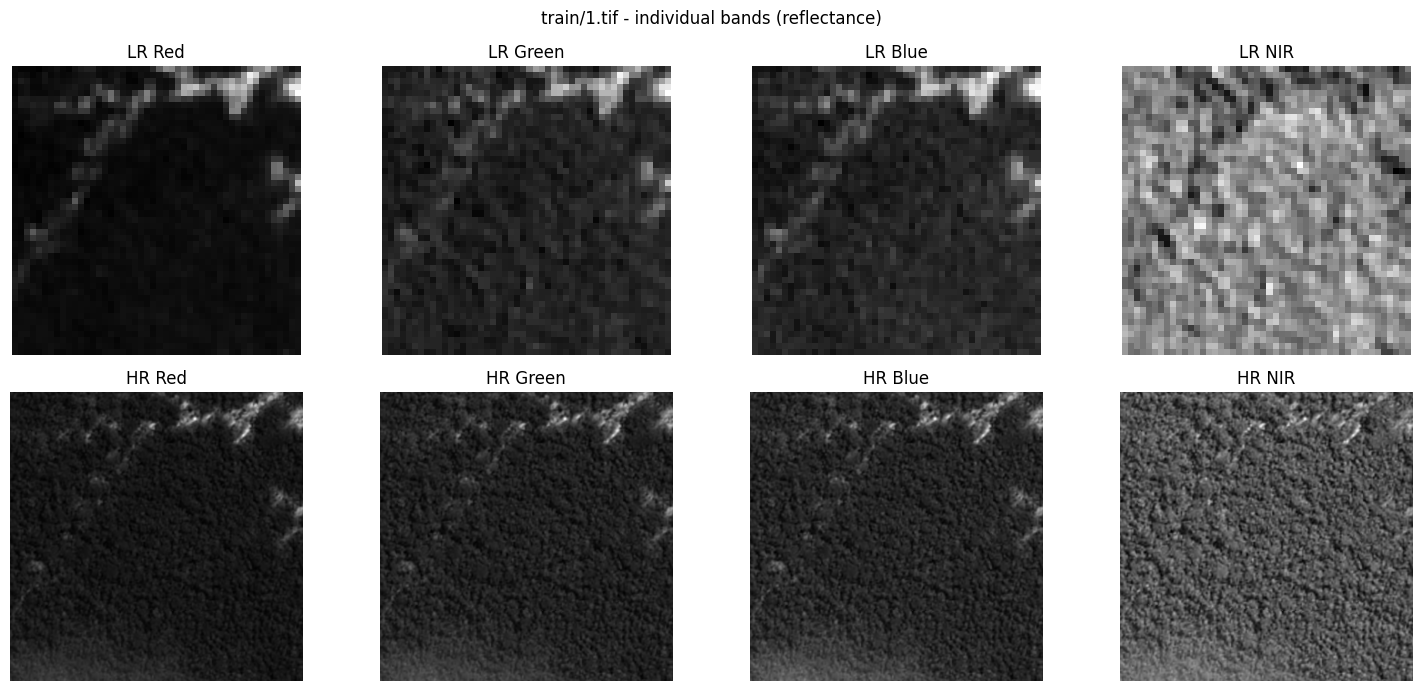

In [14]:
lr, hr = load_pair(os.path.join(ROOT, "train", "LR", names[0]),
                   os.path.join(ROOT, "train", "HR", names[0]), HR_SCALE)
fig, ax = plt.subplots(2, 4, figsize=(15, 7))
for c, bname in enumerate(CANONICAL_BAND_NAMES):
    ax[0, c].imshow(lr[..., c], cmap="gray"); ax[0, c].set_title("LR " + bname)
    ax[1, c].imshow(hr[..., c], cmap="gray"); ax[1, c].set_title("HR " + bname)
for a in ax.ravel():
    a.axis("off")
fig.suptitle("train/" + names[0] + " - individual bands (reflectance)")
plt.tight_layout(); plt.show()

## 17. LR vs HR dimensions

This is the single most important structural fact about the dataset: **HR tiles
are not all the same size.** Any code that hard-codes 320x320 is wrong.

HR height : 307 to 336
HR width  : 307 to 336
scale factor: 6.40x to 7.00x  (never a whole number)
distinct HR shapes overall: 22


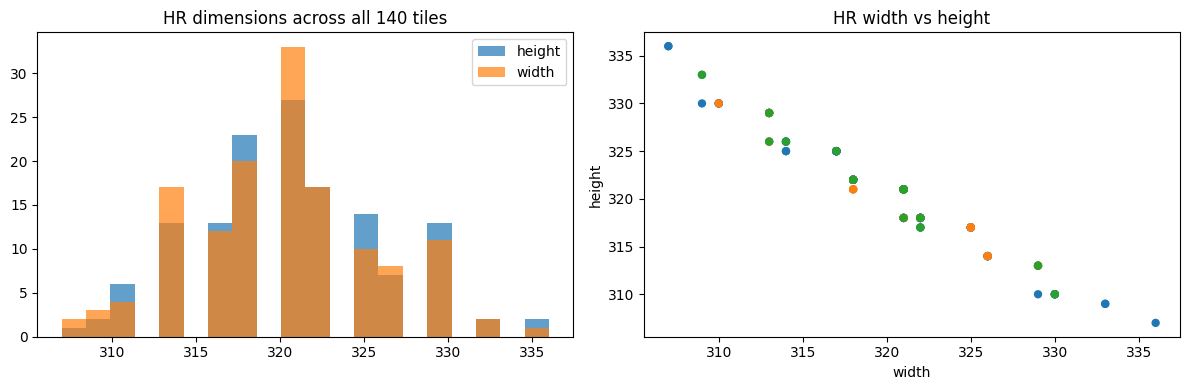

In [15]:
dims = []
for split in ["train", "val", "test"]:
    for n, lp, hp in list_pairs(ROOT, split):
        h, w = tifffile.TiffFile(hp).pages[0].shape[:2]
        dims.append({"split": split, "file": n, "hr_h": h, "hr_w": w,
                     "scale_h": h / 48, "scale_w": w / 48})
dims = pd.DataFrame(dims)

print("HR height : {} to {}".format(dims.hr_h.min(), dims.hr_h.max()))
print("HR width  : {} to {}".format(dims.hr_w.min(), dims.hr_w.max()))
print("scale factor: {:.2f}x to {:.2f}x  (never a whole number)".format(
    dims[["scale_h", "scale_w"]].values.min(), dims[["scale_h", "scale_w"]].values.max()))
print("distinct HR shapes overall:", dims.groupby(["hr_h", "hr_w"]).ngroups)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(dims.hr_h, bins=20, alpha=0.7, label="height")
ax[0].hist(dims.hr_w, bins=20, alpha=0.7, label="width")
ax[0].set_title("HR dimensions across all 140 tiles"); ax[0].legend()
ax[1].scatter(dims.hr_w, dims.hr_h, c=dims.split.map(
    {"train": "tab:blue", "val": "tab:orange", "test": "tab:green"}), s=25)
ax[1].set_xlabel("width"); ax[1].set_ylabel("height"); ax[1].set_title("HR width vs height")
plt.tight_layout(); plt.show()

### What this forces on the design

1. The model must take the **target size as an argument** and return exactly that size.
2. Only tiles of the same HR size can be stacked into one training batch. That is
   what `SameSizeBatchSampler` in `src/data.py` does.
3. The bicubic baseline must resize to the same per-image target, or the
   comparison would be unfair.

## 18. Final dataset summary

In [16]:
summary = {
    "task": "single-image super-resolution, 4 spectral bands",
    "train / val / test pairs": [report["splits"][s]["n_paired"] for s in ["train", "val", "test"]],
    "LR shape / dtype": "48 x 48 x 4, float32, reflectance",
    "HR shape / dtype": "{}..{} x {}..{} x 4, uint16, reflectance x {:g}".format(
        dims.hr_h.min(), dims.hr_h.max(), dims.hr_w.min(), dims.hr_w.max(), HR_SCALE),
    "LR band order (verified)": "[B, G, R, NIR]",
    "HR band order (verified)": "[R, G, B, NIR]  (file metadata is WRONG)",
    "canonical band order": "[R, G, B, NIR]",
    "LR GSD / HR GSD": "{:.1f} m / {:.1f} m".format(lr_gsd, hr_gsd),
    "scale factor": "{:.2f}x to {:.2f}x, variable".format(
        dims[["scale_h", "scale_w"]].values.min(), dims[["scale_h", "scale_w"]].values.max()),
    "CRS": "EPSG:4326",
    "nodata / corrupted / missing pairs": "none",
    "geographic leakage between splits": "none",
}
for k, v in summary.items():
    print("{:38s} {}".format(k, v))

os.makedirs("experiments", exist_ok=True)
dims.to_csv("experiments/dataset_dimensions.csv", index=False)
print()
print("saved experiments/dataset_dimensions.csv")

task                                   single-image super-resolution, 4 spectral bands
train / val / test pairs               [100, 20, 20]
LR shape / dtype                       48 x 48 x 4, float32, reflectance
HR shape / dtype                       307..336 x 307..336 x 4, uint16, reflectance x 10000
LR band order (verified)               [B, G, R, NIR]
HR band order (verified)               [R, G, B, NIR]  (file metadata is WRONG)
canonical band order                   [R, G, B, NIR]
LR GSD / HR GSD                        10.0 m / 1.5 m
scale factor                           6.40x to 7.00x, variable
CRS                                    EPSG:4326
nodata / corrupted / missing pairs     none
geographic leakage between splits      none

saved experiments/dataset_dimensions.csv


---

**Ready for the next notebook.** The preprocessing contract is now fixed:

```
LR tif  -> reorder bands [2,1,0,3] -> already reflectance   ->  model input
HR tif  -> keep band order         -> divide by 10000       ->  training target
prediction size = the exact size of the matching HR file
```

Next: `02_bicubic_baseline.ipynb` builds the non-neural baseline that the neural
model has to beat.